## PCA (Principal Component Analysis)
- 피처가 많은 고차원 데이터를, **정보 손실을 최소화**하면서 적은 수의 새로운 축(주성분)으로 압축하는 기법
- 쉽게 말해: 100개 컬럼 → 핵심 정보만 담은 5~10개 컬럼으로 줄이는 것

#### 1. PCA의 주요 단계

1. **표준화** — 피처마다 스케일이 다르면 큰 값을 가진 피처에 치우치므로, 평균 0·분산 1로 맞춤

2. **공분산 행렬 계산** — 피처들끼리 얼마나 같이 움직이는지(상관관계)를 행렬로 정리

3. **고유값·고유벡터 계산** — 공분산 행렬에서 추출
   - **고유벡터**: 데이터가 가장 많이 퍼져 있는 **방향** (= 새로운 축)
   - **고유값**: 그 방향으로 퍼져 있는 **정도** (= 해당 축의 중요도). 클수록 더 많은 정보를 담고 있음

4. **주성분 선택** — 고유값이 큰 순서대로 정렬하고, 전체 분산의 일정 비율(예: 95%)을 설명하는 만큼만 선택

5. **변환** — 선택한 주성분 축에 원본 데이터를 투영 → 차원이 줄어든 새 데이터 완성

#### 2. PCA의 응용
- **데이터 시각화**: 고차원 데이터를 2D/3D로 축소하여 패턴을 눈으로 확인
- **노이즈 제거**: 분산이 작은(=정보가 적은) 성분을 버려 노이즈를 줄임
- **모델 성능 개선**: 불필요한 피처를 줄여 과적합 방지 및 학습 속도 향상

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data
y = iris.target

X.shape, y.shape

((150, 4), (150,))

In [2]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()

X_scaled = ss.fit_transform(X)

In [5]:
from sklearn.decomposition import PCA

# PCA 모델 생성 - 주성분 2개
pca = PCA(n_components=2)

# 모델 학습(규칙 설정)
pca.fit(X_scaled)

# 데이터 변환(PCA 적용)
X_pca = pca.transform(X_scaled)

X_pca[:10]

array([[-2.26470281,  0.4800266 ],
       [-2.08096115, -0.67413356],
       [-2.36422905, -0.34190802],
       [-2.29938422, -0.59739451],
       [-2.38984217,  0.64683538],
       [-2.07563095,  1.48917752],
       [-2.44402884,  0.0476442 ],
       [-2.23284716,  0.22314807],
       [-2.33464048, -1.11532768],
       [-2.18432817, -0.46901356]])

In [8]:
pca_df = pd.DataFrame(X_pca, columns = ['PC1', 'PC2'])

pca_df.head()

,PC1,PC2
0,-2.264703,0.480027
1,-2.080961,-0.674134
2,-2.364229,-0.341908
3,-2.299384,-0.597395
4,-2.389842,0.646835


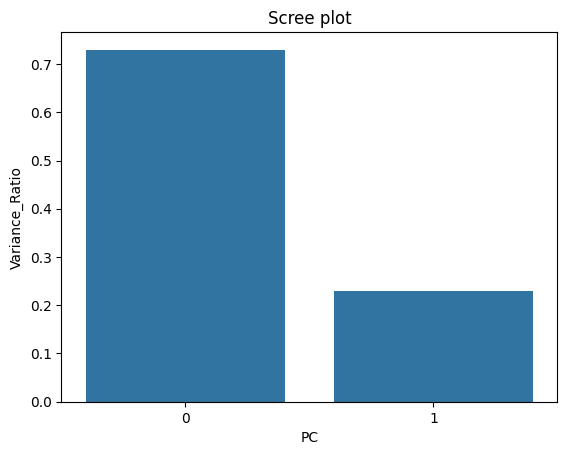

In [9]:
## 차원축소 후의 축이 각각 전체 데이터에 대해 어느 정도의 설명력을 가지는지 확인

var = pca.explained_variance_ratio_ 

sns.barplot(var)

plt.xlabel('PC')
plt.ylabel('Variance_Ratio')
plt.title('Scree plot')

plt.show()

In [10]:
## cumsum -> 누적합 구하기

cum_var = np.cumsum(var)   # 누적 분산비율 구하기

cum_var

array([0.72962445, 0.95813207])

In [11]:
print('원본 데이터 형태:', X_scaled.shape)
print('PCA 적용된 데이터 형태:', X_pca.shape)
print('PCA 적용된 특성의 중요도:', pca.explained_variance_)
print('PCA 적용된 특성의 중요도 비율:', pca.explained_variance_ratio_)

원본 데이터 형태: (150, 4)
PCA 적용된 데이터 형태: (150, 2)
PCA 적용된 특성의 중요도: [2.93808505 0.9201649 ]
PCA 적용된 특성의 중요도 비율: [0.72962445 0.22850762]


In [12]:
target_names = iris.target_names
target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

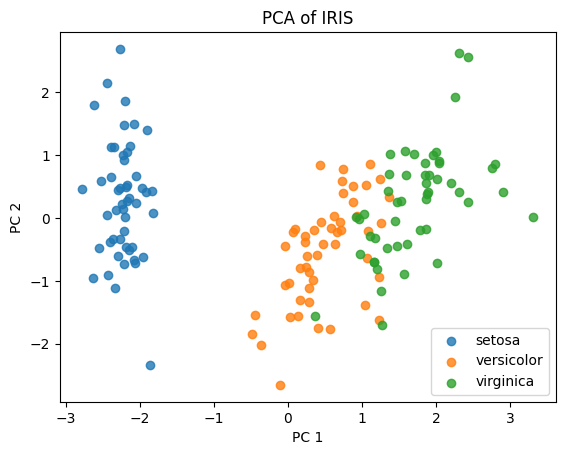

In [ ]:
# 2개의 차원으로 축소되었기 때문에 2차원 평면에 시각화 가능.

for i, target in enumerate(target_names):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], alpha=.8, label=target)
    
plt.legend()
plt.title('PCA of IRIS')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.show()

#### 와인 데이터셋 시각화 실습

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
wine = pd.read_csv('./dataset/wine.csv')

wine.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Customer_Segment
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1


In [18]:
# 학습 데이터 추출
X = wine.iloc[:, :-1].values

# 타겟 데이터 추출
y = wine.iloc[:, -1].values

In [19]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()

X_scaled = ss.fit_transform(X)

In [20]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X_scaled)

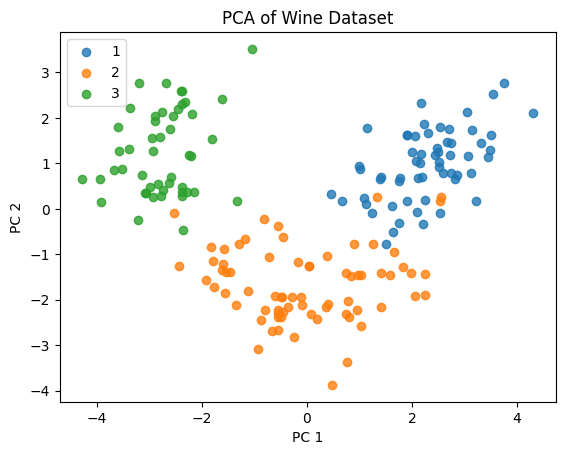

In [21]:
for i in range(1,4):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], alpha=.8, label=i)
    
plt.legend()
plt.title('PCA of Wine Dataset')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.show()